In [2]:
import pandas as pd

In [3]:
df= pd.read_csv(r"C:/Users/feggi/Downloads/FILE TO KEEP workings/Telco_Cleaned.csv", sep=';')

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

Statistical summary

In [21]:
print(df.describe(include='all'))

        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7032   7032    7032.000000    7032       7032  7032.000000   
unique        7032      2            NaN       2          2          NaN   
top     7590-VHVEG   Male            NaN      No         No          NaN   
freq             1   3549            NaN    3639       4933          NaN   
mean           NaN    NaN       0.162400     NaN        NaN    32.421786   
std            NaN    NaN       0.368844     NaN        NaN    24.545260   
min            NaN    NaN       0.000000     NaN        NaN     1.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecurity  ...  \
count         

Services VS Churn

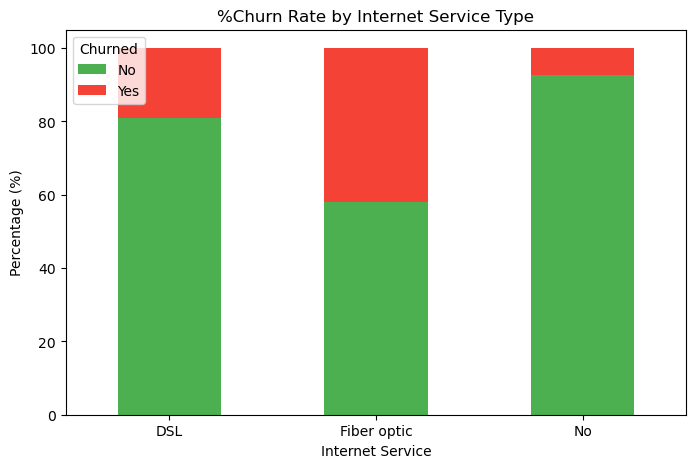

In [22]:
Churn_Service = pd.crosstab(df['InternetService'], df['Churn'] , normalize = 'index') *100
#plotting
Churn_Service.plot(kind ='bar', stacked= True, figsize=(8,5), color=['#4caf50', '#f44336'])
plt.title('%Churn Rate by Internet Service Type')
plt.ylabel('Percentage (%)')
plt.xlabel('Internet Service')
plt.xticks(rotation=0)
plt.legend(title = 'Churned')
plt.show()

Churn by contract and Internet Service

In [23]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


chart showing customers that have both multiple lines and phoneservice and the ones that do not

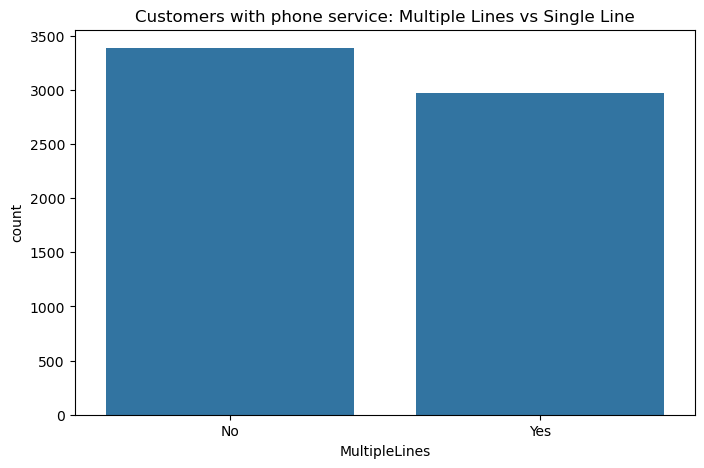

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
phone_customers = df[df['PhoneService']=='Yes']
plt.figure(figsize=(8,5))
sns.countplot(data=phone_customers, x='MultipleLines')
plt.title('Customers with phone service: Multiple Lines vs Single Line')
plt.show()

Relating Male and female to check the gender which churned and which did not

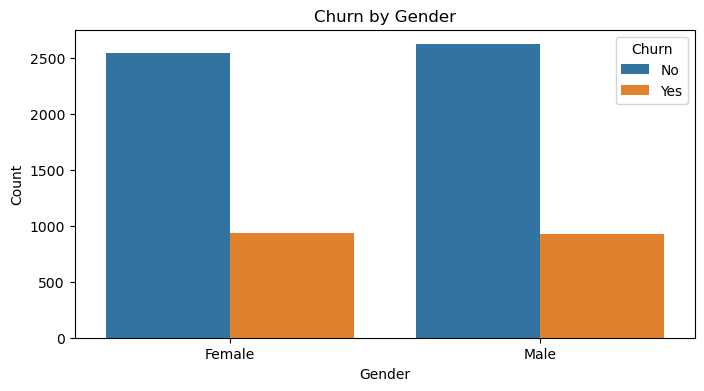

In [25]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Churn Distribution

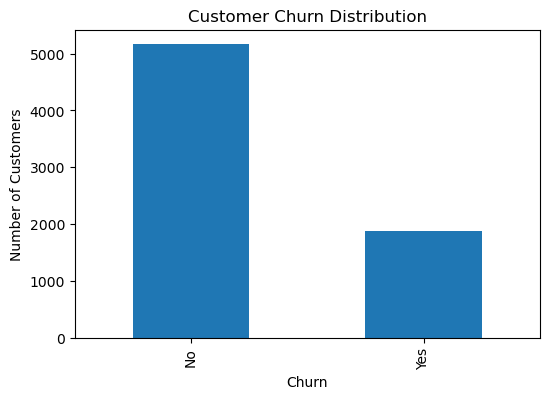

In [26]:
plt.figure(figsize= (6,4))
df['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()


Tenure Distribution

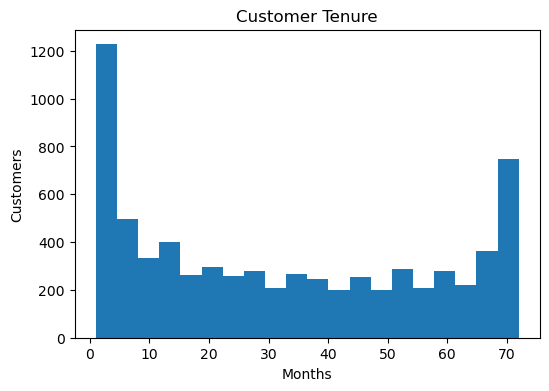

In [27]:
plt.figure(figsize=(6,4))
plt.hist(df['tenure'], bins =20)
plt.title('Customer Tenure')
plt.xlabel('Months')
plt.ylabel('Customers')
plt.show()

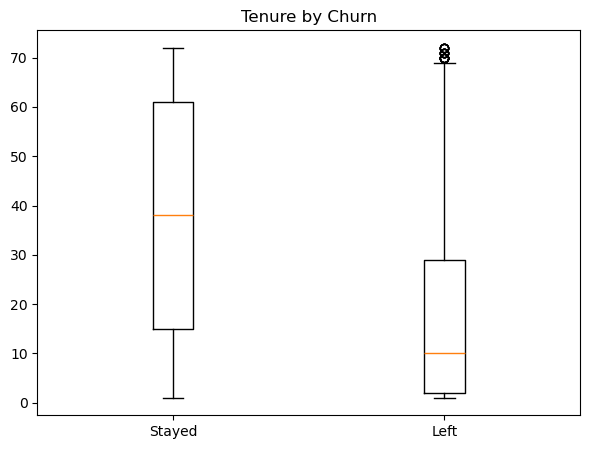

In [28]:
plt.figure(figsize=(7,5))

plt.boxplot([
    df[df['Churn']=='No']['tenure'],
    df[df['Churn']=='Yes']['tenure']
])

plt.xticks([1,2],['Stayed','Left'])

plt.title('Tenure by Churn')

plt.show()

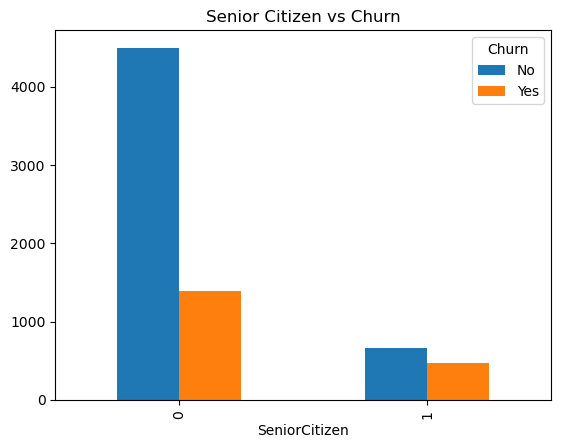

In [29]:
pd.crosstab(df['SeniorCitizen'], df['Churn']).plot(kind='bar')

plt.title('Senior Citizen vs Churn')

plt.show()

Highest service in revenue

<function matplotlib.pyplot.show(close=None, block=None)>

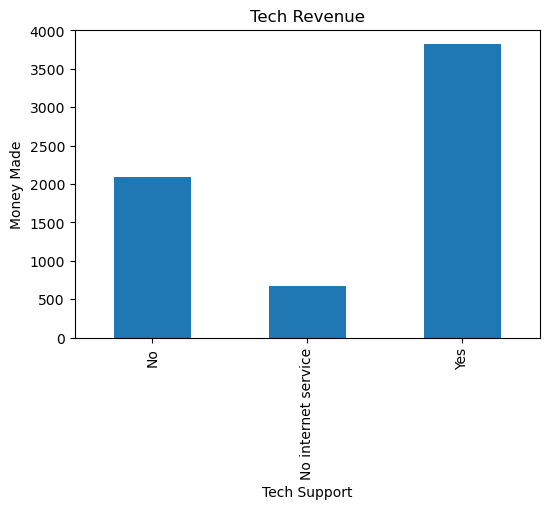

In [30]:
Tech = df.groupby('TechSupport')['TotalCharges'].mean()
plt.figure(figsize=(6,4))
Tech.plot(kind='bar')
plt.title('Tech Revenue')
plt.xlabel('Tech Support')
plt.ylabel('Money Made')
plt.show

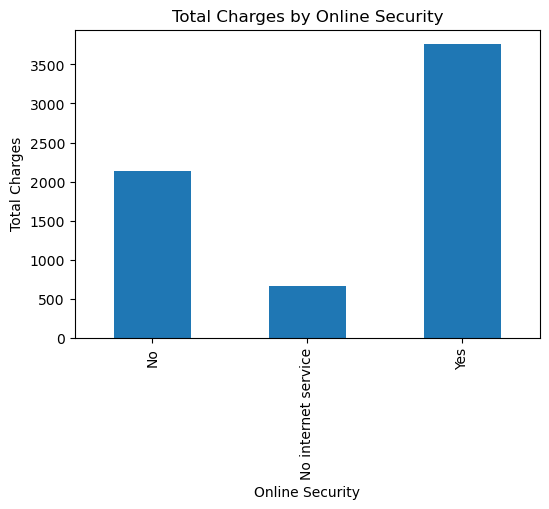

In [31]:
Security=df.groupby('OnlineSecurity')['TotalCharges'].mean()
plt.figure(figsize=(6,4))
Security.plot(kind='bar')
plt.title('Total Charges by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Total Charges')
plt.show()

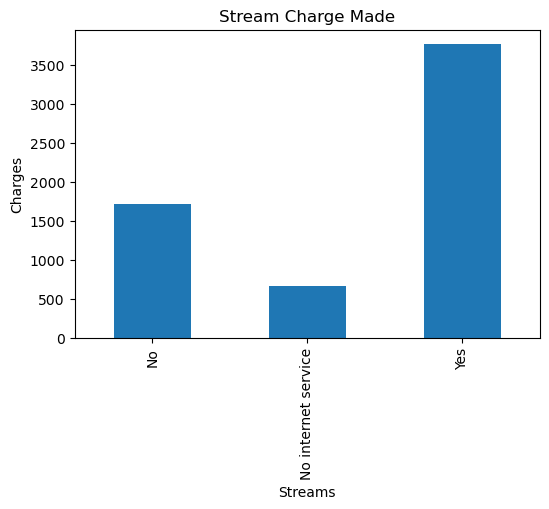

In [32]:
Stream=df.groupby('StreamingMovies')['TotalCharges'].mean()
plt.figure(figsize=(6,4))
Stream.plot(kind='bar')
plt.title('Stream Charge Made')
plt.xlabel('Streams')
plt.ylabel('Charges')
plt.show()

Pie Chart

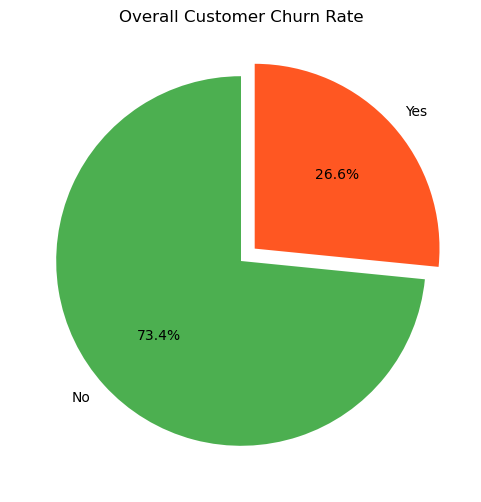

In [33]:
plt.figure(figsize=(6, 6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'], startangle=90, explode=(0, 0.1))
plt.title('Overall Customer Churn Rate')
plt.ylabel('')
plt.show()

LINE CHART: Average Monthly Charges over Customer Tenure

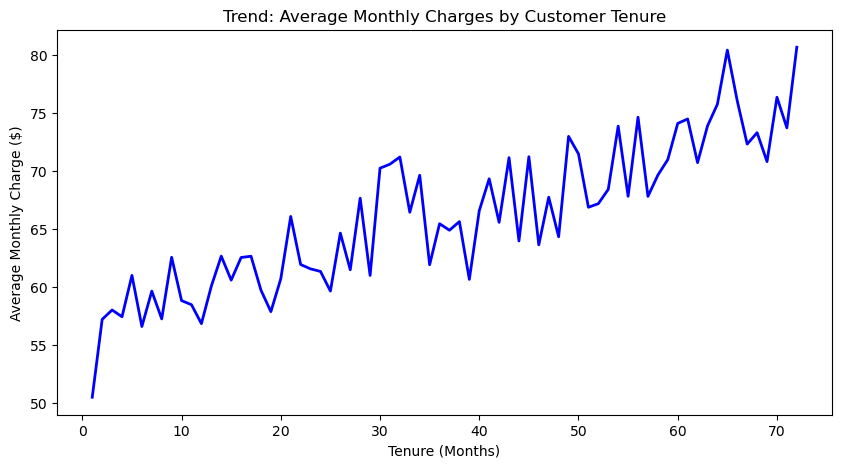

In [34]:
plt.figure(figsize=(10, 5))
# Group by tenure and find average charges
tenure_charges = df.groupby('tenure')['MonthlyCharges'].mean().reset_index()
sns.lineplot(data=tenure_charges, x='tenure', y='MonthlyCharges', color='blue', linewidth=2)
plt.title('Trend: Average Monthly Charges by Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Average Monthly Charge ($)')
plt.show()


CORRELATION HEATMAP

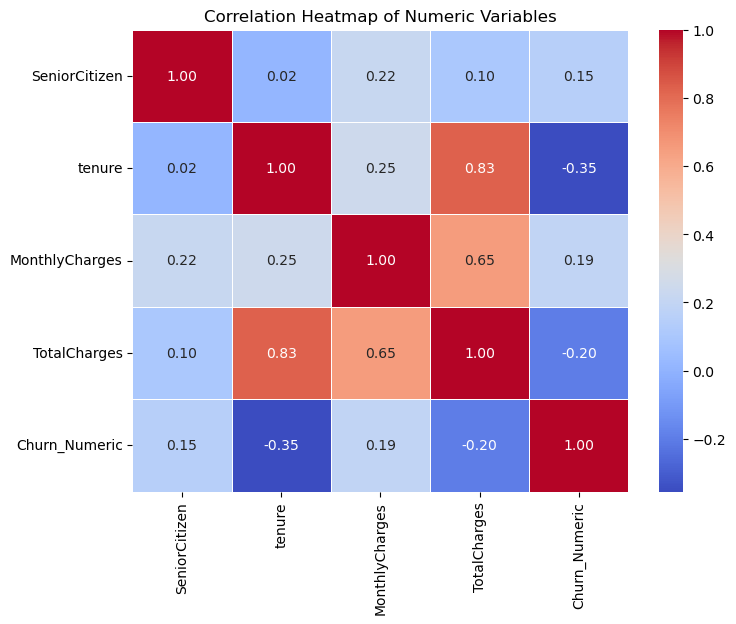

In [35]:
plt.figure(figsize=(8, 6))
# Convert Churn to binary for correlation mapping
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()